<a href="https://colab.research.google.com/github/Rogerio-mack/IA_2026S1/blob/main/Resumo_ML_supervisionado_scikit_learn.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Aprendizado Supervisionado: Regressão e Classificação `scikit-learn`**

> ## **Pontos Chave**:

1. Saiba diferenciar as tarefas de Classificação e Regressão de Aprendizado de Máquina Supervisionado
2. Entenda que, em ambos os casos, existem vários modelos que podem ser aplicados
3. Entenda como funcionam os *estimadores* do scikit-learn, classes a que são associados métodos como `fit()`, `score()` etc.


In [47]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


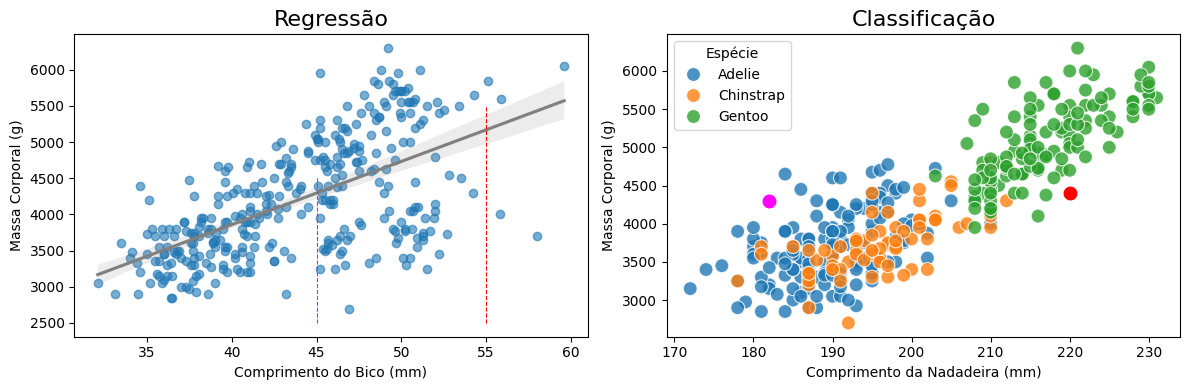

In [65]:
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.regplot(x='bill_length_mm', y='body_mass_g', data=df, ax=axes[0],
            scatter_kws={'alpha':0.6}, line_kws={'color':'gray'})
axes[0].set_title('Regressão',fontsize=16)
axes[0].set_xlabel('Comprimento do Bico (mm)')
axes[0].set_ylabel('Massa Corporal (g)')

sns.scatterplot(x='flipper_length_mm', y='body_mass_g', hue='species', data=df, ax=axes[1],
                s=100, alpha=0.8)
axes[1].set_title('Classificação',fontsize=16)
axes[1].set_xlabel('Comprimento da Nadadeira (mm)')
axes[1].set_ylabel('Massa Corporal (g)')
axes[1].legend(title='Espécie')

axes[0].vlines(x=55, ymin=2500, ymax=5500, linestyles='--', color='red', lw=0.8)
axes[1].scatter(x=220, y=4400, color='red', lw=4)

axes[0].vlines(x=45, ymin=2500, ymax=4500, linestyles='--', color='magenta', lw=0.8)
axes[1].scatter(x=182, y=4300, color='magenta', lw=4)

plt.tight_layout()
plt.show()

In [66]:
#@markdown just run
class mydisplay(object):
    # Adaptado de https://jakevdp.github.io/PythonDataScienceHandbook/index.html
    """Display HTML representation of multiple objects"""
    template = """<div style="float: left; padding: 10px;">
    <hr>
    <p style='font-family:"Courier New", Courier, monospace'>{0}</p><hr>{1}
    </div>"""
    def __init__(self, *args):
        self.args = args

    def _repr_html_(self):
        return '\n'.join(self.template.format(a, eval(a)._repr_html_())
                         for a in self.args)

    def __repr__(self):
        return '\n\n'.join(a + '\n' + repr(eval(a))
                           for a in self.args)

## Regressão, $X ⟼ y \space \space$ `rótulo com valores contínuos (numéricos reais)`

In [70]:
mydisplay('df[["island","bill_length_mm","bill_depth_mm"]].head()', 'df[["body_mass_g"]].head()')

df[["island","bill_length_mm","bill_depth_mm"]].head()
      island  bill_length_mm  bill_depth_mm
0  Torgersen            39.1           18.7
1  Torgersen            39.5           17.4
2  Torgersen            40.3           18.0
3  Torgersen             NaN            NaN
4  Torgersen            36.7           19.3

df[["body_mass_g"]].head()
   body_mass_g
0       3750.0
1       3800.0
2       3250.0
3          NaN
4       3450.0

## Classificação, $X ⟼ y \space \space$ `rótulos com valores discretos (classes)`

In [71]:
mydisplay('df[["body_mass_g","bill_length_mm","bill_depth_mm"]].head()', 'df[["island"]].head()')

df[["body_mass_g","bill_length_mm","bill_depth_mm"]].head()
   body_mass_g  bill_length_mm  bill_depth_mm
0       3750.0            39.1           18.7
1       3800.0            39.5           17.4
2       3250.0            40.3           18.0
3          NaN             NaN            NaN
4       3450.0            36.7           19.3

df[["island"]].head()
      island
0  Torgersen
1  Torgersen
2  Torgersen
3  Torgersen
4  Torgersen

# Regressores

> ## **Pontos Chave**:

1. Cite alguns estimadores de regressão.
2. Entenda o uso dos estimadores: model ⟶  fit  ⟶  predict
3. Entenda a diferença de um modelo de regressão linear e modelos não lineares
4. Quais são as principais métricas de modelos de Regressão
5. Extra: Entenda por que não devemos empregar esses modelos para previsão direta de Séries Temporais  



6.053800571947932e-08


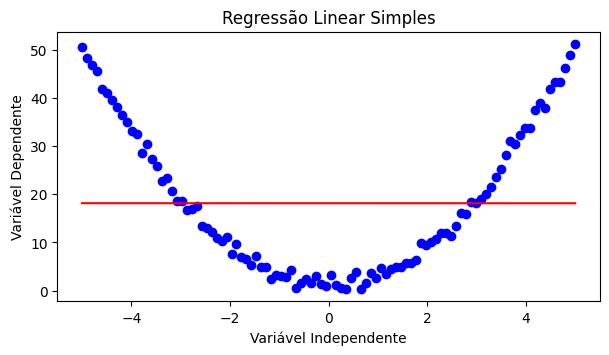

In [44]:
import numpy as np
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor, AdaBoostRegressor
from sklearn.neural_network import MLPRegressor

# Gerar dados de exemplo para regressão

plt.figure(figsize=(7,3.5))

# Dados de exemplo
X = np.linspace(-5,5,100).reshape(-1, 1)
y = 2 * X**2 + 1 + np.random.randn(len(X), 1)

# Criar o modelo de regressão linear
model = LinearRegression()
# model = KNeighborsRegressor()

# Treinar o modelo
model.fit(X, y)

# Fazer previsões
y_pred = model.predict(X)

print(model.score(X,y))

# Plotar os resultados
plt.scatter(X, y, color='blue')
plt.plot(X, y_pred, color='red')
plt.title('Regressão Linear Simples')
plt.xlabel('Variável Independente')
plt.ylabel('Variável Dependente')
plt.show()

# Exibir os coeficientes, somente para regressão linear

# print(f'Intercepto: {model.intercept_}')
# print(f'Coeficiente (inclinação): {model.coef_[0]}')

In [46]:
from sklearn.metrics import mean_squared_error, mean_absolute_error

mse = mean_squared_error(y, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y, y_pred)

print(f'Mean Squared Error (MSE): {mse:.2f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.2f}')
print(f'Mean Absolute Error (MAE): {mae:.2f}')

Mean Squared Error (MSE): 228.72
Root Mean Squared Error (RMSE): 15.12
Mean Absolute Error (MAE): 13.01


# Classificadores

> ## **Pontos Chave**:

1. Cite alguns estimadores de classificação
2. Entenda o uso dos estimadores: model ⟶  fit  ⟶  predict
3. Entenda a métrica de acuracidade


Acurácia do modelo: 0.83


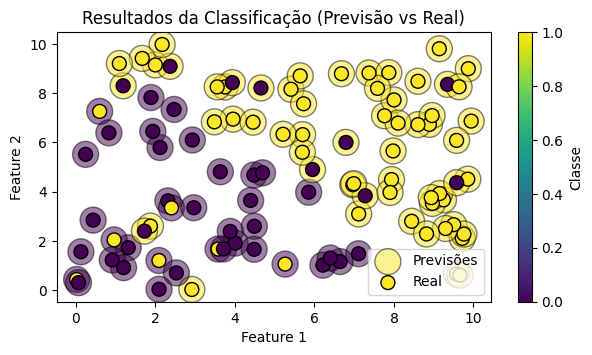

In [2]:
import numpy as np
from sklearn.model_selection import train_test_split

from sklearn.neighbors import KNeighborsClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression # É classificação
from sklearn.svm import SVC
from sklearn.gaussian_process import GaussianProcessClassifier
from sklearn.gaussian_process.kernels import RBF
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, AdaBoostClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier

from sklearn.metrics import accuracy_score

# Gerar dados de exemplo para classificação
# Duas classes separadas linearmente
X = np.random.rand(100, 2) * 10
y = (X[:, 0] + X[:, 1] > 10).astype(int) # Crie rótulos de classe com base em uma regra simples
y[30:60] = y[50:80]


# Criar um modelo de classificação (K-Neighbors Classifier)
model = KNeighborsClassifier(n_neighbors=5)

# Treinar o modelo
model.fit(X, y)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X)

# Avaliar o modelo
accuracy = accuracy_score(y, y_pred)
print(f'Acurácia do modelo: {accuracy:.2f}')

# Opcional: Visualizar os resultados (para 2D)
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.scatter(X[:, 0], X[:, 1], c=y_pred, cmap='viridis', marker='o', edgecolors='k', label='Previsões', s=350, alpha=0.5)
plt.scatter(X[:, 0], X[:, 1], c=y, cmap='viridis', marker='o', edgecolors='k', s=100, label='Real')
plt.title('Resultados da Classificação (Previsão vs Real)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.colorbar(label='Classe')
plt.show()

# Conjuntos de Treinamento e Teste

> ## **Pontos Chave**:

1. O que são sobre ajuste e sub ajuste
2. Eles podem ocorrer também em modelos de Regressão?
3. Como separar dados de Treinamento e Teste

Acurácia do modelo: 0.75


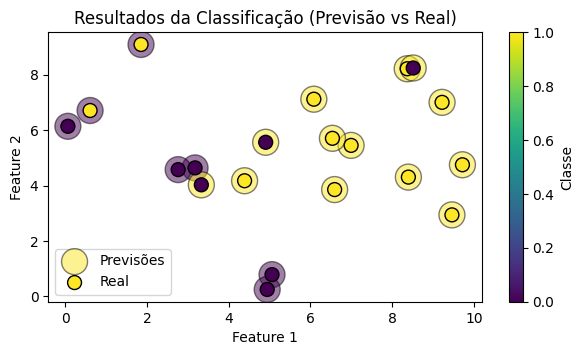

In [5]:
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score

# Gerar dados de exemplo para classificação
# Duas classes separadas linearmente
X = np.random.rand(100, 2) * 10
y = (X[:, 0] + X[:, 1] > 10).astype(int) # Crie rótulos de classe com base em uma regra simples
y[30:60] = y[50:80]

# Dividir os dados em conjuntos de treino e teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Criar um modelo de classificação (K-Neighbors Classifier)
model = KNeighborsClassifier(n_neighbors=5)

# Treinar o modelo
model.fit(X_train, y_train)

# Fazer previsões no conjunto de teste
y_pred = model.predict(X_test)

# Avaliar o modelo
accuracy = accuracy_score(y_test, y_pred)
print(f'Acurácia do modelo: {accuracy:.2f}')

# Opcional: Visualizar os resultados (para 2D)
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 3.5))
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_pred, cmap='viridis', marker='o', edgecolors='k', label='Previsões', s=350, alpha=0.5)
plt.scatter(X_test[:, 0], X_test[:, 1], c=y_test, cmap='viridis', marker='o', edgecolors='k', s=100, label='Real')
plt.title('Resultados da Classificação (Previsão vs Real)')
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.legend()
plt.colorbar(label='Classe')
plt.show()

# Métricas: Classification Report

> ## **Pontos Chave**:

1. Entenda que a acuracidade, em alguns casos, pode ser uma métrica limitada
2. Entenda as métricas de Precisão, Revocação e F1-score

In [4]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.69      0.69      0.69        13
           1       0.43      0.43      0.43         7

    accuracy                           0.60        20
   macro avg       0.56      0.56      0.56        20
weighted avg       0.60      0.60      0.60        20



# Exercício

Crie e compare dois diferentes modelos de classificação da origem dos pinguins ("ilha do Pinguim") a partir dos demais atributos.

> ## **Pontos Chave**:

1. Entenda o por quê e como são algumas das principais operações de preparação dos dados (não é necessário entender a codificação, que está pronta, mas o por quê e como os dados são transformados)

> 1.1. Dados ausentes

> 1.2. Hot Encode

> 1.3. Normalização




In [21]:
import pandas as pd
import seaborn as sns

df = sns.load_dataset('penguins')
df.head()

,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,Male
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,Female
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,Female
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,Female


## Preparação dos Dados (**RESOLVIDO**)

Exclui os dados ausentes se houverem, excluindo as linhas.


### Dropna

In [22]:
df.isnull().sum().sum() > 0

np.True_

In [23]:
len_pre_drop = len(df)

In [24]:
df = df.dropna().reset_index(drop=True)


In [25]:
print(f'Número de linhas com valores ausentes excluídas: {len_pre_drop - len(df)}')

Número de linhas com valores ausentes excluídas: 11


### Dados de treinamento e teste

Emprega 30% dos dados para teste, `random_state=1` e conjuntos estratificados pelo atributo classe (variável objetivo).

In [26]:
# Separando os dados de treinamento e teste
X = df.drop(columns='island')
y = df['island']

X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.3, random_state=1)

In [27]:
display(X_train.head()), display(y_train.head())

,species,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex
114,Adelie,36.2,17.2,187.0,3150.0,Female
217,Gentoo,50.0,15.2,218.0,5700.0,Male
112,Adelie,35.7,17.0,189.0,3350.0,Female
15,Adelie,37.8,18.3,174.0,3400.0,Female
206,Chinstrap,51.9,19.5,206.0,3950.0,Male


,island
114,Torgersen
217,Biscoe
112,Torgersen
15,Biscoe
206,Dream


(None, None)

### Hot Encode



In [30]:
from sklearn.preprocessing import OneHotEncoder

# Identify non-numeric columns in X_train
non_numeric_cols = X_train.select_dtypes(exclude=np.number).columns

# Apply one-hot encode to non-numeric columns
encoder = OneHotEncoder(sparse_output=False, drop='first')
X_train_encoded = encoder.fit_transform(X_train[non_numeric_cols])
X_train_encoded = pd.DataFrame(X_train_encoded, columns=encoder.get_feature_names_out(non_numeric_cols))

# Drop original non-numeric columns and concatenate encoded columns
X_train = X_train.drop(columns=non_numeric_cols).reset_index(drop=True)
X_train = pd.concat([X_train, X_train_encoded], axis=1)

X_test_encoded = encoder.transform(X_test[non_numeric_cols])
X_test_encoded = pd.DataFrame(X_test_encoded, columns=encoder.get_feature_names_out(non_numeric_cols))

# Drop original non-numeric columns and concatenate encoded columns
X_test = X_test.drop(columns=non_numeric_cols).reset_index(drop=True)
X_test = pd.concat([X_test, X_test_encoded], axis=1)


In [31]:
display(X_train.head())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,sex_Male
0,36.2,17.2,187.0,3150.0,0.0,0.0,0.0
1,50.0,15.2,218.0,5700.0,0.0,1.0,1.0
2,35.7,17.0,189.0,3350.0,0.0,0.0,0.0
3,37.8,18.3,174.0,3400.0,0.0,0.0,0.0
4,51.9,19.5,206.0,3950.0,1.0,0.0,1.0


### Normalização




In [32]:
from sklearn.preprocessing import StandardScaler

# Normalizando os dados
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)


In [40]:
for i in range(5):
  print(X_train[i])

[-1.44571054 -0.01191718 -1.04223518 -1.34605215 -0.50937163 -0.74386379
 -1.0394023 ]
[ 1.07682998 -1.02162753  1.22388905  1.88235389 -0.50937163  1.34433214
  0.96209139]
[-1.53710693 -0.11288822 -0.89603361 -1.09284383 -0.50937163 -0.74386379
 -1.0394023 ]
[-1.15324207  0.54342351 -1.99254533 -1.02954175 -0.50937163 -0.74386379
 -1.0394023 ]
[ 1.42413628  1.14924972  0.34667967 -0.33321888  1.96320316 -0.74386379
  0.96209139]


In [35]:
# Obter as colunas numéricas originais de X
numeric_cols = X.select_dtypes(include=np.number).columns.tolist()

# Obter as colunas codificadas do encoder
encoded_cols = encoder.get_feature_names_out(non_numeric_cols).tolist()

# Combinar todas as colunas
all_cols = numeric_cols + encoded_cols

# Recriar X_train como um DataFrame
X_train_df = pd.DataFrame(X_train, columns=all_cols)

display(X_train_df.head())

,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,species_Chinstrap,species_Gentoo,sex_Male
0,-1.445711,-0.011917,-1.042235,-1.346052,-0.509372,-0.743864,-1.039402
1,1.076830,-1.021628,1.223889,1.882354,-0.509372,1.344332,0.962091
2,-1.537107,-0.112888,-0.896034,-1.092844,-0.509372,-0.743864,-1.039402
3,-1.153242,0.543424,-1.992545,-1.029542,-0.509372,-0.743864,-1.039402
4,1.424136,1.149250,0.346680,-0.333219,1.963203,-0.743864,0.962091


# Modelo 1

In [41]:
# Seu código aqui

# Modelo 2

In [42]:
# Seu código aqui